In [1]:
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from pinecone_text.sparse import BM25Encoder
import pprint
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from api_utils import Utils
import math

# Dataset

In [2]:
ds = load_dataset("ashraq/fashion-product-images-small", split="train")
ds

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image'],
    num_rows: 44072
})

In [3]:
ds[0]

{'id': 15970,
 'gender': 'Men',
 'masterCategory': 'Apparel',
 'subCategory': 'Topwear',
 'articleType': 'Shirts',
 'baseColour': 'Navy Blue',
 'season': 'Fall',
 'year': 2011.0,
 'usage': 'Casual',
 'productDisplayName': 'Turtle Check Men Navy Blue Shirt',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=60x80>}

In [4]:
SAMPLING_SIZE = 20000
ds_sample = ds.shuffle(seed=42).select(range(SAMPLING_SIZE))

images = ds_sample['image']
metadata = ds_sample.remove_columns(['image'])

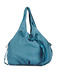

In [5]:
images[0]

In [6]:
np.array(images[0]).shape

(80, 60, 3)

# Sparse Embedding for key-word search

In [7]:
corpus = metadata['productDisplayName']
len(corpus)

20000

## Method 1: TF-IDF

In [8]:
tf_idf = TfidfVectorizer()
corpus_vectorized = tf_idf.fit_transform(corpus)
corpus_vectorized.shape

(20000, 5913)

In [9]:
word2idx = tf_idf.vocabulary_
len(word2idx)

5913

- **Each document is encoded into a sparse vector with dimension of 8562 (which equals to vocabulary size). That means each position in a vector of a document mapped to a word**
- **A sparse vector is a vector including some values != 0, the rest = 0. Because a document just includes some words from vocabulary, if words doesnt appear in that document, the value of that word in vector will be 0**

In [10]:
doc_0 = corpus[0]
indices_0 = [word2idx[w] for w in corpus[0].lower().split()]

print(f"Document 0             : {doc_0}")
print(f"Word -> Index in Doc 0 : {str(indices_0)}")
print()
print(f"Values : {corpus_vectorized[0].data}")
print(f"Indices: {corpus_vectorized[0].indices}")

Document 0             : Baggit Women Blue Bag
Word -> Index in Doc 0 : [889, 5806, 1109, 888]

Values : [0.63853552 0.25076188 0.35484576 0.6351971 ]
Indices: [ 889 5806 1109  888]


- **Each word is mapped to an index from vocabulary, and a value computed from TF-IDF method**
- **The indices mean these positions in a vector have the value != 0, the other positions/indices in that vector = 0**

---

## Method 2: BM25

In [11]:
bm25 = BM25Encoder()
bm25.fit(corpus)

  0%|          | 0/20000 [00:00<?, ?it/s]

In [12]:
doc_0_using_encode_documents = bm25.encode_documents(corpus[0])
doc_0_using_encode_queries = bm25.encode_queries(corpus[0])

pprint.pprint(doc_0_using_encode_documents)
print()
pprint.pprint(doc_0_using_encode_queries)

{'indices': [2566285421, 720498841, 3905155331, 3184722936],
 'values': [0.5178388084523843,
            0.5178388084523843,
            0.5178388084523843,
            0.5178388084523843]}

{'indices': [2566285421, 720498841, 3905155331, 3184722936],
 'values': [0.37306055685303796,
            0.09280862075909924,
            0.1675543924020713,
            0.3665764299857915]}


- **Source Code:** https://github.com/pinecone-io/pinecone-text/blob/main/pinecone_text/sparse/bm25_encoder.py

- **Index of a word in an encoded document = Hash(word). That's why the index is so large, out of vocabulary**

- **Comparision between 2 methods:**

| Aspect                  | `encode_documents`                                                | `encode_queries`                                                    |
| ----------------------- | ----------------------------------------------------------------- | ------------------------------------------------------------------- |
| Purpose                 | Represent documents for storage                                   | Represent queries for search                                        |
| Weighting               | TF normalized (no IDF)                                            | IDF normalized (emphasizes rare terms)                              |
| Length sensitivity      | TF scaled by document length                                      | Not length-sensitive; IDF-focused                                   |
| Values in vector        | Often similar across terms                                        | Vary according to token rarity                                      |
| Dependency              | Only depends on the document itself                               | Depends on corpus statistics (DF, N, length)                        |
| Stability & update cost | Stable; does not change when corpus is updated, low recomputation | Dynamic; changes if corpus grows or DF changes, computed on-the-fly |


> **During similarity computation, the TF of the document is multiplied by the IDF of the query, effectively producing a TF*IDF weighting that highlights terms both frequent in the document and rare in the corpus.**

---

# Dense Embedding for semantic search

In [13]:
embedding_model = SentenceTransformer('sentence-transformers/clip-ViT-B-32')  # both text or image to vector

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [14]:
image_embedded = embedding_model.encode([images[0]])
image_embedded.shape

(1, 512)

# Single Hybrid Index

In [15]:
hybrid_index = Utils.create_index('hybrid-index', dimension=512, metric="dotproduct")

Index 'hybrid-index' already exists → deleting ...
Deleted 'hybrid-index' successfully!
Creating index 'hybrid-index' ...
Index 'hybrid-index' created successfully!


In [16]:
def upsert_hybrid(ds_images, ds_metadata, index, embedding_model, bm25_encoder, batch_size=512):

    for i in tqdm(range(0, len(ds_images), batch_size)):
        i_end = min(i+batch_size, len(ds_images))

        # Create ids, values, metadata
        ids = [str(id) for id in range(i, i_end)]
        img_emb = embedding_model.encode(ds_images[i:i_end])
        meta = [meta_dict for meta_dict in ds_metadata.select(range(i, i_end))]

        # Create sparse_values
        meta_for_sparse = [
            " ".join(f"{k}: {v}" for k, v in m.items() if k not in ['id', 'year'])
            for m in meta
        ]
        # arg in method must be str, so we " ".join, and also we dont want to encode id, year
        meta_enc = bm25_encoder.encode_documents(meta_for_sparse)

        # Upsert
        current_batch = list(map(
            lambda x: {'id': x[0], 'values': x[1], 'sparse_values': x[2], 'metadata': x[3]},
            zip(ids, img_emb, meta_enc, meta)
        ))

        index.upsert(current_batch)

In [17]:
upsert_hybrid(images, metadata, hybrid_index, embedding_model, bm25, batch_size=1000)

  0%|          | 0/20 [00:00<?, ?it/s]

In [18]:
hybrid_index.describe_index_stats()

{'dimension': 512,
 'index_fullness': 0.0,
 'metric': 'dotproduct',
 'namespaces': {'': {'vector_count': 20000}},
 'total_vector_count': 20000,
 'vector_type': 'dense'}

# Hybrid Search

**Docs here:** https://docs.pinecone.io/guides/search/hybrid-search

In [19]:
def hybrid_score_norm(dense, sparse, alpha: float):
    """Hybrid score using a convex combination

    alpha * dense + (1 - alpha) * sparse

    Args:
        dense: Array of floats representing
        sparse: a dict of `indices` and `values`
        alpha: scale between 0 and 1
    """
    if alpha < 0 or alpha > 1:
        raise ValueError("Alpha must be between 0 and 1")

    hsparse = {
        'indices': sparse['indices'],
        'values':  [v * (1 - alpha) for v in sparse['values']]
    }

    hdense = [v * alpha for v in dense]

    return hdense, hsparse

In [20]:
def search_hybrid(question, index=hybrid_index, embedding_model=embedding_model, bm25_encoder=bm25, top_k=10, alpha=None):

    dense = embedding_model.encode(question).tolist()
    sparse = bm25_encoder.encode_queries(question)

    if alpha:
        dense, sparse = hybrid_score_norm(dense, sparse, alpha)

    result = index.query(
        vector=dense,
        sparse_vector=sparse,
        top_k=top_k,
        include_metadata=True
    )

    return result.matches

In [21]:
def display_images(matches, images, metadata, num_images=6, cols=3):
    matches = matches[:num_images]
    rows = math.ceil(len(matches) / cols)

    plt.figure(figsize=(5*cols, 5*rows))

    for idx, match_ in enumerate(matches):
        img_id = int(match_.id)
        score = str(round(match_.score, 4))
        img = images[img_id]
        meta = metadata[img_id]
        title = meta.get("productDisplayName", f"ID {str(img_id)}") + "\n" + score

        plt.subplot(rows, cols, idx+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(title, fontsize=11, wrap=True)

    plt.tight_layout()
    plt.show()

In [22]:
question = "women’s floral printed kurta with three-quarter sleeves"

matches_dense = search_hybrid(question, alpha=0.9)
matches_sparse = search_hybrid(question, alpha=0.1)

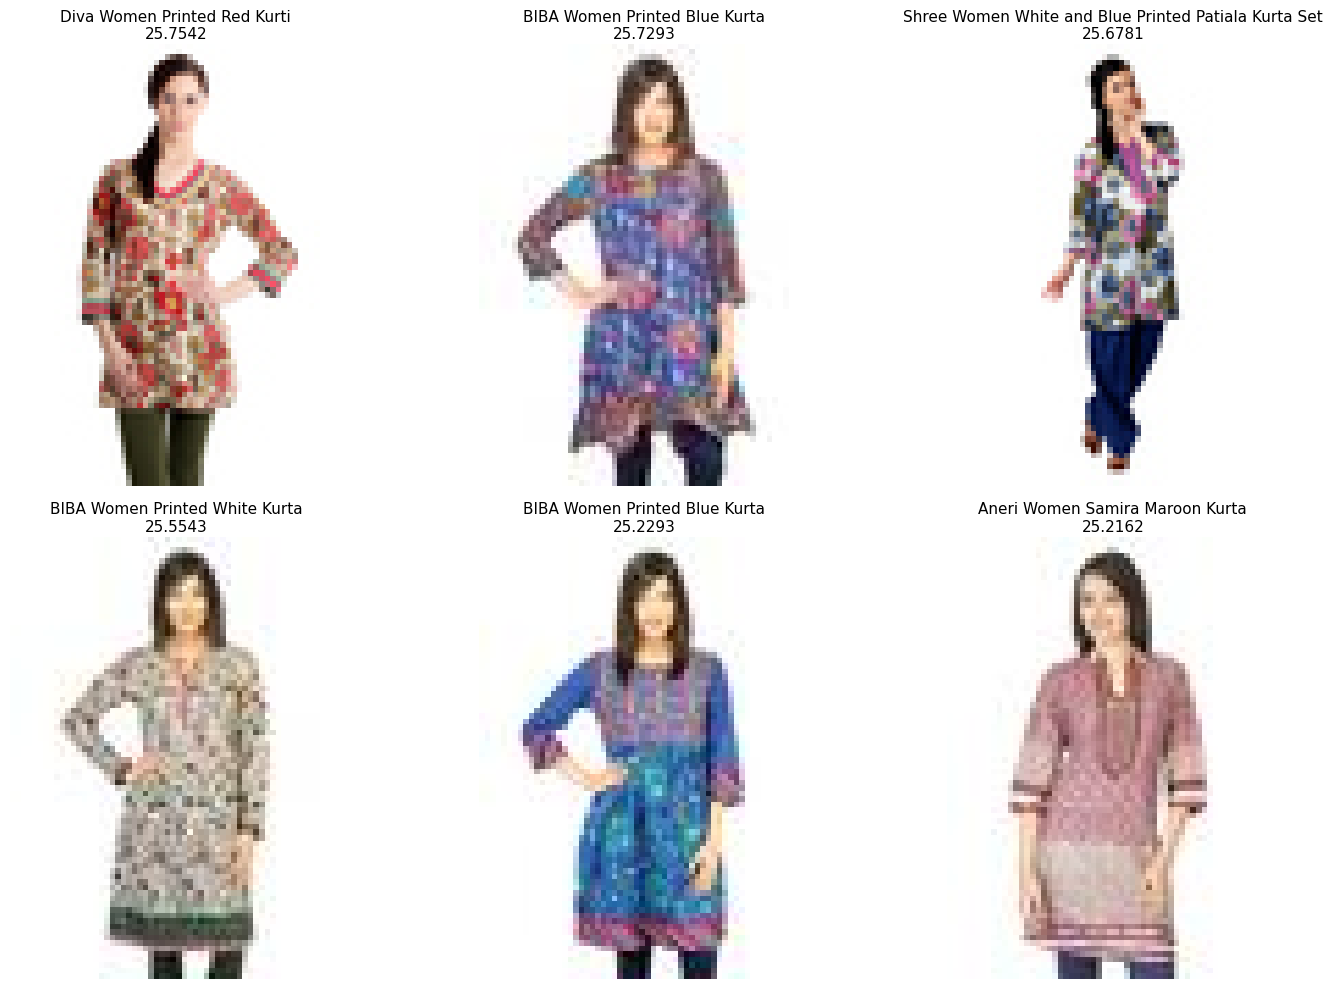

In [23]:
display_images(matches_dense, images, metadata)

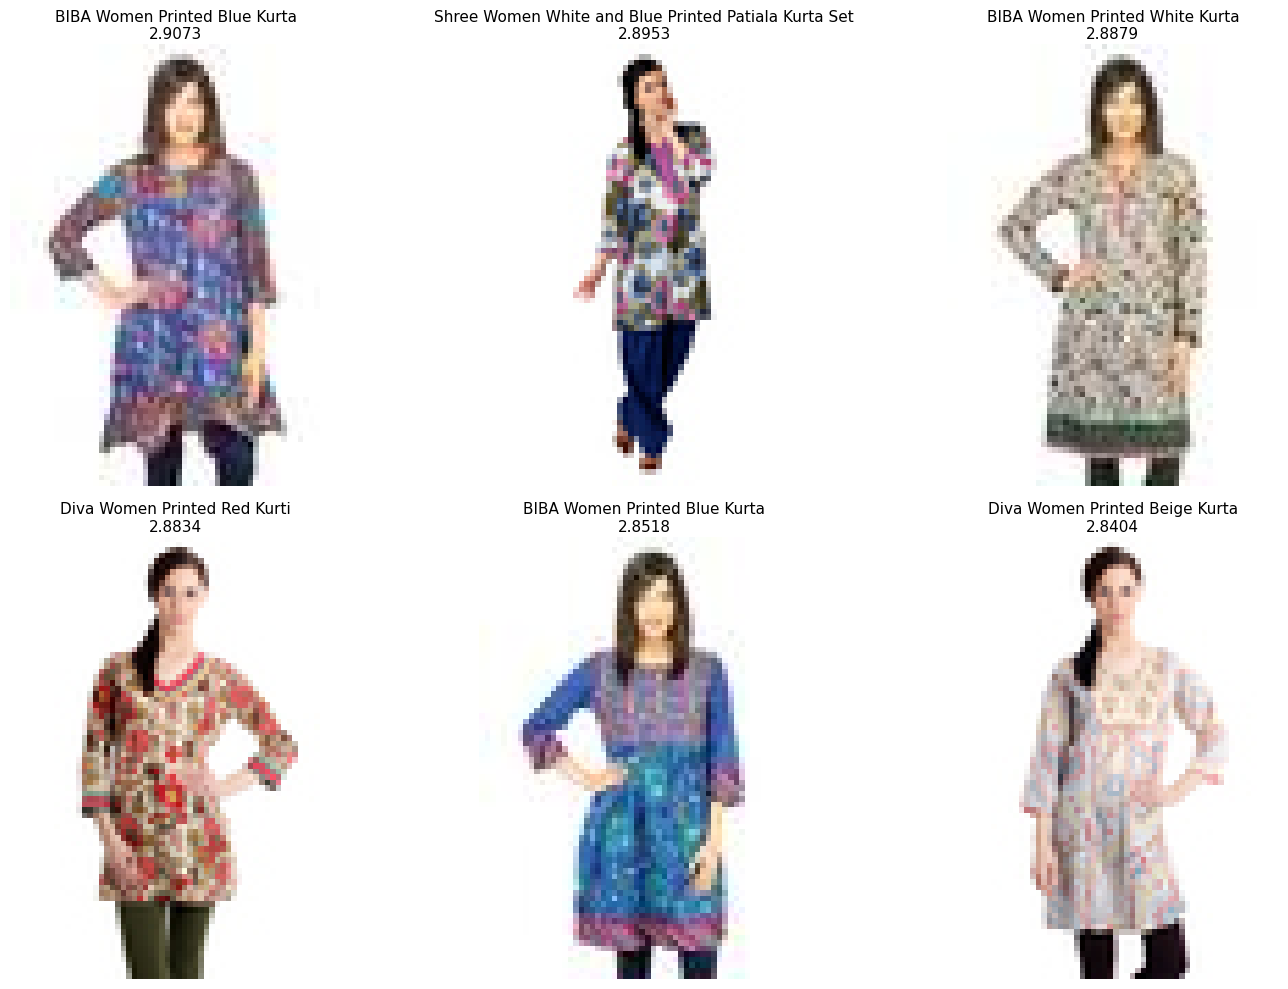

In [24]:
display_images(matches_sparse, images, metadata)